In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
       print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nfl-big-data-bowl-2026-prediction/sample_submission.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/test_input.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/test.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/input_2023_w17.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w05.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w10.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/input_2023_w03.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w18.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/input_2023_w05.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w11.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w12.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w16.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w06.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/train/input_2023_w18.csv


Some rules
- Need to code that attackers always go left to right
- 

# The input data contains tracking data before the pass is thrown

- game_id: Game identifier, unique (numeric)
- play_id: Play identifier, not unique across games (numeric)
- player_to_predict: whether or not the x/y prediction for this player will be scored (bool)
- nfl_id: Player identification number, unique across players (numeric)
- frame_id: Frame identifier for each play/type, starting at 1 for each game_id/play_id/file type (input or output) (numeric)
play_direction: Direction that the offense is moving (left or right)
absolute_yardline_number: Distance from end zone for possession team (numeric)
player_name: player name (text)
player_height: player height (ft-in)
player_weight: player weight (lbs)
player_birth_date: birth date (yyyy-mm-dd)
player_position: the player's position (the specific role on the field that they typically play)
player_side: team player is on (Offense or Defense)
player_role: role player has on play (Defensive Coverage, Targeted Receiver, Passer or Other Route Runner)
x: Player position along the long axis of the field, generally within 0 - 120 yards. (numeric)
y: Player position along the short axis of the field, generally within 0 - 53.3 yards. (numeric)
s: Speed in yards/second (numeric)
a: Acceleration in yards/second^2 (numeric)
o: orientation of player (deg)
dir: angle of player motion (deg)
num_frames_output: Number of frames to predict in output data for the given game_id/play_id/nfl_id. (numeric)
ball_land_x: Ball landing position position along the long axis of the field, generally within 0 - 120 yards. (numeric)
ball_land_y: Ball landing position along the short axis of the field, generally within 0 - 53.3 yards. (numeric)
output_2023_w[01-18].csv
The output data contains tracking data after the pass is thrown.

game_id: Game identifier, unique (numeric)
play_id: Play identifier, not unique across games (numeric)
nfl_id: Player identification number, unique across players. (numeric)
frame_id: Frame identifier for each play/type, starting at 1 for each game_id/play_id/ file type (input or output). The maximum value for a given game_id, play_id and nfl_id will be the same as the num_frames_output value from the corresponding input file. (numeric)
x: Player position along the long axis of the field, generally within 0-120 yards. (TARGET TO PREDICT)
y: Player position along the short axis of the field, generally within 0 - 53.3 yards. (TARGET TO PREDICT)

In [3]:
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#       df = pd.read_csv(os.path.join(dirname, filename))
#        print(os.path.join(dirname, filename))


input_df = pd.read_csv("/kaggle/input/nfl-big-data-bowl-2026-prediction/train/input_2023_w08.csv")
output_df =  pd.read_csv("/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w08.csv")


In [4]:
input_df.head(100)

game = input_df[input_df['game_id'] == 	2023102600]
play = game[game['play_id'] == 109]
play = play[play['player_to_predict']]
play

player = play[play['player_role'] == 'Targeted Receiver']



out_game = output_df[output_df['game_id'] == 	2023102600]
out_play = out_game[out_game['play_id'] == 109]
out_play

#play['player_role'].unique()
#play['player_name'].unique()

,game_id,play_id,nfl_id,frame_id,x,y
0,2023102600,109,54650,1,70.87,35.44
1,2023102600,109,54650,2,70.45,35.58
2,2023102600,109,54650,3,70.05,35.74
3,2023102600,109,54650,4,69.66,35.92
4,2023102600,109,54650,5,69.28,36.11
5,2023102600,109,54650,6,68.94,36.26
6,2023102600,109,54650,7,68.62,36.36
7,2023102600,109,54650,8,68.31,36.44
8,2023102600,109,54650,9,68.03,36.47
9,2023102600,109,54650,10,67.76,36.48


In [5]:
output_df.head()

,game_id,play_id,nfl_id,frame_id,x,y
0,2023102600,109,54650,1,70.87,35.44
1,2023102600,109,54650,2,70.45,35.58
2,2023102600,109,54650,3,70.05,35.74
3,2023102600,109,54650,4,69.66,35.92
4,2023102600,109,54650,5,69.28,36.11


### Okay lets make a base prediction

### EDA

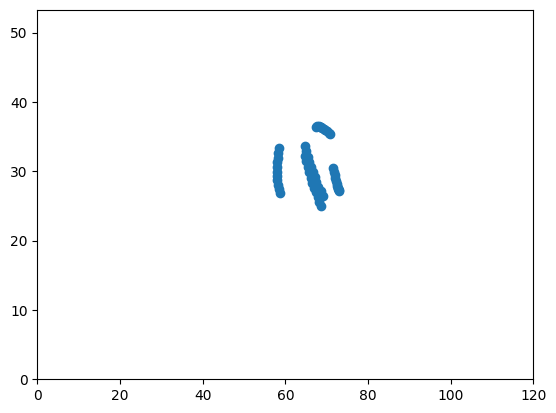

/tmp/ipykernel_37/2562419189.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap(cmap_name, n)


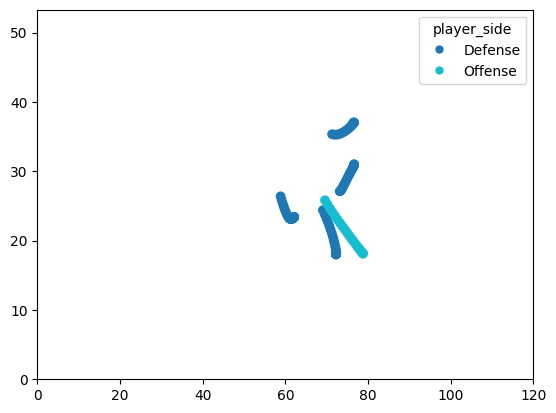

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D

def pitch_plot(x, y, color=None, cmap_name='tab10', title=None):
    # Ensure Series (keeps indexes for alignment)
    x = pd.Series(x)
    y = pd.Series(y)

    fig, ax = plt.subplots()

    if color is None:
        # No color argument: just plot points
        ax.scatter(x, y)
    else:
        # Align color to x/y rows by index (prevents length mismatches)
        c = pd.Series(color).reindex(x.index)

        if len(c) != len(x):
            raise ValueError(f"'color' length {len(c)} does not match x/y length {len(x)} after alignment.")

        # If color is non-numeric (categorical), map to codes + legend
        if not pd.api.types.is_numeric_dtype(c):
            cats = pd.Categorical(c)
            codes = cats.codes  # -1 for NaN; map those to a default color
            n = max(len(cats.categories), 1)
            cmap = get_cmap(cmap_name, n)
            # Replace -1 (NaN) with a distinct index at the end, if any NaNs exist
            if (codes == -1).any():
                codes = pd.Series(codes)
                codes[codes == -1] = n - 1
            ax.scatter(x, y, c=codes, cmap=cmap)

            # Legend (skip NaN label)
            handles = [
                Line2D([], [], marker='o', linestyle='', label=str(cat),
                       markerfacecolor=cmap(i), markeredgecolor='none')
                for i, cat in enumerate(cats.categories)
                if str(cat) != 'nan'
            ]
            if handles:
                ax.legend(handles=handles, title=getattr(c, 'name', 'Category'), loc='best')
        else:
            # Numeric color values → use default normalization/colorbar
            sc = ax.scatter(x, y, c=c)
            plt.colorbar(sc, ax=ax)

    ax.set(xlim=(0, 120), ylim=(0, 53.3))
    if title:
        ax.set_title(title)
    plt.show()


# 1) No color argument
pitch_plot(out_play['x'], out_play['y'])

# 2) Same-df categorical colors
pitch_plot(play['x'], play['y'], play['player_side'])

In [7]:
out_play['part'] = 'output'
play['part'] = 'input'

/tmp/ipykernel_37/3835258924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out_play['part'] = 'output'


In [8]:
pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/sample_submission.csv')

,id,x,y
0,2024120805_74_54586_1,0,0
1,2024120805_74_54586_2,0,0
2,2024120805_74_54586_3,0,0
3,2024120805_74_54586_4,0,0
4,2024120805_74_54586_5,0,0
...,...,...,...
5832,2025010515_3902_55112_26,0,0
5833,2025010515_3902_55112_27,0,0
5834,2025010515_3902_55112_28,0,0
5835,2025010515_3902_55112_29,0,0


In [9]:
test_input = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/test_input.csv')
test_input = test_input[test_input['player_to_predict']== True]
summary = test_input[['game_id', 'play_id', 'nfl_id', 'num_frames_output']].drop_duplicates()
summary

,game_id,play_id,nfl_id,num_frames_output
45,2024120805,74,54586,11
75,2024120805,74,53472,11
150,2024120805,74,57213,11
165,2024120805,143,57233,10
363,2024120805,143,41233,10
...,...,...,...,...
49363,2025010515,3902,46122,30
49402,2025010515,3902,52991,30
49441,2025010515,3902,42771,30
49480,2025010515,3902,54718,30


In [10]:
pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/sample_submission.csv')

,id,x,y
0,2024120805_74_54586_1,0,0
1,2024120805_74_54586_2,0,0
2,2024120805_74_54586_3,0,0
3,2024120805_74_54586_4,0,0
4,2024120805_74_54586_5,0,0
...,...,...,...
5832,2025010515_3902_55112_26,0,0
5833,2025010515_3902_55112_27,0,0
5834,2025010515_3902_55112_28,0,0
5835,2025010515_3902_55112_29,0,0


In [11]:
pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/test.csv')

,game_id,play_id,nfl_id,frame_id
0,2024120805,74,54586,1
1,2024120805,74,54586,2
2,2024120805,74,54586,3
3,2024120805,74,54586,4
4,2024120805,74,54586,5
...,...,...,...,...
5832,2025010515,3902,55112,26
5833,2025010515,3902,55112,27
5834,2025010515,3902,55112,28
5835,2025010515,3902,55112,29


In [15]:

# Keep only unique combinations
summary = test_input[['game_id', 'play_id', 'nfl_id', 'num_frames_output']].drop_duplicates()

# Expand each row into multiple rows (one per frame)
expanded = (
    summary
    .loc[summary.index.repeat(summary['num_frames_output'])]
    .assign(frame=lambda df: df.groupby(df.index).cumcount() + 1)
)

# Create the ID column
expanded['id'] = (
    expanded['game_id'].astype(str) + '_' +
    expanded['play_id'].astype(str) + '_' +
    expanded['nfl_id'].astype(str) + '_' +
    expanded['frame'].astype(str)
)

# Add placeholder x,y columns
expanded['x'] = 0
expanded['y'] = 0

# Select final columns and reset index
submission = expanded[['id', 'x', 'y']].reset_index(drop=True)  
submission

,id,x,y
0,2024120805_74_54586_1,0,0
1,2024120805_74_54586_2,0,0
2,2024120805_74_54586_3,0,0
3,2024120805_74_54586_4,0,0
4,2024120805_74_54586_5,0,0
...,...,...,...
5832,2025010515_3902_55112_26,0,0
5833,2025010515_3902_55112_27,0,0
5834,2025010515_3902_55112_28,0,0
5835,2025010515_3902_55112_29,0,0
